In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("krishnakamath/movielens-32m-movies-enriched-with-SIDs", split="train")

# Access an example
example = dataset[0]
print(example['title'])
print(example['genres'])
print(example['all_mpnet_base_v2_embedding'][:5]) # Print first 5 dimensions
print(example['semantic_id'])

# You can iterate through the dataset
for movie in dataset.select(range(5)): # Get first 5 movies
    print(f"Title: {movie['title']}, SID: {movie['semantic_id']}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/232M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/233M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87555 [00:00<?, ? examples/s]

Toy Story (1995)
['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']
[0.06720573455095291, 0.020947396755218506, -0.009524949826300144, -0.03053339384496212, 0.030397778376936913]
[663, 789, 595, 51]
Title: Toy Story (1995), SID: [663, 789, 595, 51]
Title: Jumanji (1995), SID: [663, 608, 916, 694]
Title: Grumpier Old Men (1995), SID: [71, 56, 916, 509]
Title: Waiting to Exhale (1995), SID: [71, 54, 923, 540]
Title: Father of the Bride Part II (1995), SID: [71, 337, 452, 115]


In [12]:
df = pd.DataFrame(dataset)
df

,movie_id,title,genres,plot_summary,director,stars,all_mpnet_base_v2_embedding,semantic_id
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",Toy Story follows the adventures of a group of...,John Lasseter,"[Tom Hanks, Tim Allen, Don Rickles]","[0.06720573455095291, 0.020947396755218506, -0...","[663, 789, 595, 51]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]","In 'Jumanji', a magical board game unleashes a...",Joe Johnston,"[Robin Williams, Kirsten Dunst, Bonnie Hunt]","[0.06835135817527771, 0.009235946461558342, -0...","[663, 608, 916, 694]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]","In this sequel to 'Grumpy Old Men', lifelong f...",Howard Deutch,"[Jack Lemmon, Walter Matthau, Sophia Loren]","[0.057237111032009125, 0.02801183983683586, 0....","[71, 56, 916, 509]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",Waiting to Exhale is a drama film that follows...,Forest Whitaker,"[Whitney Houston, Angela Bassett, Loretta Devine]","[0.0328509584069252, -0.005377753172069788, -0...","[71, 54, 923, 540]"
4,5,Father of the Bride Part II (1995),[Comedy],"In 'Father of the Bride Part II', George Banks...",Charles Shyer,"[Steve Martin, Diane Keaton, Martin Short]","[0.050540994852781296, -0.02159050479531288, -...","[71, 337, 452, 115]"
...,...,...,...,...,...,...,...,...
87550,292731,The Monroy Affaire (2022),[Drama],The Monroy Affaire is a gripping thriller that...,Director Q,"[Actor P, Actress Q, Actor R]","[0.027108805254101753, 0.1181483268737793, 0.0...","[24, 227, 564, 29]"
87551,292737,Shelter in Solitude (2023),"[Comedy, Drama]",Shelter in Solitude is a thought-provoking dra...,Director S,"[Actor S, Actress T, Actor U]","[0.05782131478190422, 0.08979707211256027, 0.0...","[24, 193, 663, 342]"
87552,292753,Orca (2023),[Drama],Orca is a gripping thriller that follows the h...,Director V,"[Actor V, Actress W, Actor X]","[0.06655322760343552, 0.09820783138275146, 0.0...","[24, 806, 893, 95]"
87553,292755,The Angry Breed (1968),[Drama],The Angry Breed is a gritty drama that delves ...,Director W,"[Actor Y, Actress Z, Actor A1]","[0.01779353991150856, 0.0022069138940423727, 0...","[889, 295, 66, 81]"


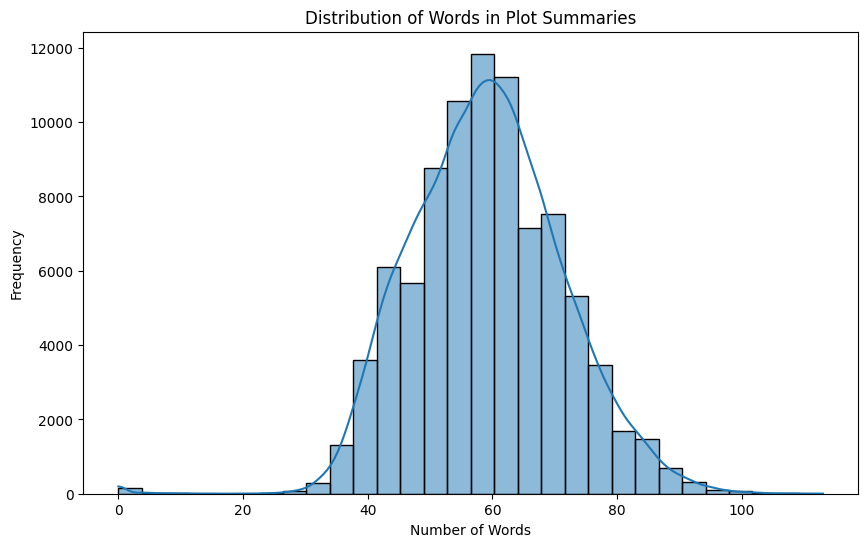

In [13]:
df['words_in_plot_summary'] = df['plot_summary'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['words_in_plot_summary'], bins=30, kde=True)
plt.title('Distribution of Words in Plot Summaries')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [19]:
df

,movie_id,title,genres,plot_summary,director,stars,all_mpnet_base_v2_embedding,semantic_id,words_in_plot_summary,words_in_plot_summary_less_than_25
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",Toy Story follows the adventures of a group of...,John Lasseter,"[Tom Hanks, Tim Allen, Don Rickles]","[0.06720573455095291, 0.020947396755218506, -0...","[663, 789, 595, 51]",77,False
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]","In 'Jumanji', a magical board game unleashes a...",Joe Johnston,"[Robin Williams, Kirsten Dunst, Bonnie Hunt]","[0.06835135817527771, 0.009235946461558342, -0...","[663, 608, 916, 694]",90,False
2,3,Grumpier Old Men (1995),"[Comedy, Romance]","In this sequel to 'Grumpy Old Men', lifelong f...",Howard Deutch,"[Jack Lemmon, Walter Matthau, Sophia Loren]","[0.057237111032009125, 0.02801183983683586, 0....","[71, 56, 916, 509]",79,False
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",Waiting to Exhale is a drama film that follows...,Forest Whitaker,"[Whitney Houston, Angela Bassett, Loretta Devine]","[0.0328509584069252, -0.005377753172069788, -0...","[71, 54, 923, 540]",83,False
4,5,Father of the Bride Part II (1995),[Comedy],"In 'Father of the Bride Part II', George Banks...",Charles Shyer,"[Steve Martin, Diane Keaton, Martin Short]","[0.050540994852781296, -0.02159050479531288, -...","[71, 337, 452, 115]",91,False
...,...,...,...,...,...,...,...,...,...,...
87550,292731,The Monroy Affaire (2022),[Drama],The Monroy Affaire is a gripping thriller that...,Director Q,"[Actor P, Actress Q, Actor R]","[0.027108805254101753, 0.1181483268737793, 0.0...","[24, 227, 564, 29]",49,False
87551,292737,Shelter in Solitude (2023),"[Comedy, Drama]",Shelter in Solitude is a thought-provoking dra...,Director S,"[Actor S, Actress T, Actor U]","[0.05782131478190422, 0.08979707211256027, 0.0...","[24, 193, 663, 342]",51,False
87552,292753,Orca (2023),[Drama],Orca is a gripping thriller that follows the h...,Director V,"[Actor V, Actress W, Actor X]","[0.06655322760343552, 0.09820783138275146, 0.0...","[24, 806, 893, 95]",55,False
87553,292755,The Angry Breed (1968),[Drama],The Angry Breed is a gritty drama that delves ...,Director W,"[Actor Y, Actress Z, Actor A1]","[0.01779353991150856, 0.0022069138940423727, 0...","[889, 295, 66, 81]",55,False
